In [38]:
import kagglehub

datasetPath = kagglehub.dataset_download("souhagaa/nasa-access-log-dataset-1995")
print("Path to dataset files:", datasetPath)

Path to dataset files: /home/dawidk/.cache/kagglehub/datasets/souhagaa/nasa-access-log-dataset-1995/versions/1


In [39]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.getOrCreate()

# Schemat ramki danych

In [40]:
dataFrame = spark.read.csv(datasetPath, header=True, inferSchema=True)
dataFrame.show(10)
dataFrame.printSchema()

+---+-----------+---------+------+--------------------+--------+-----+
|_c0|       host|     time|method|                 url|response|bytes|
+---+-----------+---------+------+--------------------+--------+-----+
|  0|***.novo.dk|805465029|   GET|           /ksc.html|     200| 7067|
|  1|***.novo.dk|805465031|   GET|/images/ksclogo-m...|     200| 5866|
|  2|***.novo.dk|805465051|   GET|/images/MOSAIC-lo...|     200|  363|
|  3|***.novo.dk|805465053|   GET|/images/USA-logos...|     200|  234|
|  4|***.novo.dk|805465054|   GET|/images/NASA-logo...|     200|  786|
|  5|***.novo.dk|805465058|   GET|/images/WORLD-log...|     200|  669|
|  6|***.novo.dk|805465068|   GET|/shuttle/missions...|     200| 8678|
|  7|***.novo.dk|805465071|   GET|/images/launchmed...|     200|11853|
|  8|***.novo.dk|805465153|   GET|/images/KSC-logos...|     200| 1204|
|  9|***.novo.dk|805465157|   GET|/images/NASA-logo...|     200|  786|
+---+-----------+---------+------+--------------------+--------+-----+
only s

26/04/15 00:30:05 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: , host, time, method, url, response, bytes
 Schema: _c0, host, time, method, url, response, bytes
Expected: _c0 but found: 
CSV file: file:///home/dawidk/.cache/kagglehub/datasets/souhagaa/nasa-access-log-dataset-1995/versions/1/data.csv


# Ilość rekordów i zamiana typu danych kolumny `time`

In [41]:
print("Liczba rekordów:", dataFrame.count())

Liczba rekordów: 2965561


In [42]:
dataFrame = dataFrame.withColumn("time", dataFrame["time"].cast("timestamp"))
dataFrame.printSchema()

root
 |-- _c0: integer (nullable = true)
 |-- host: string (nullable = true)
 |-- time: timestamp (nullable = true)
 |-- method: string (nullable = true)
 |-- url: string (nullable = true)
 |-- response: integer (nullable = true)
 |-- bytes: integer (nullable = true)



# Analiza kolumny bytes - sprawdzenie błędnych wartości

In [43]:
from pyspark.sql.functions import col, isnan, isnull

# Sprawdzenie wartości null i NaN w kolumnie bytes
print("=== Statystyki kolumny bytes ===")
dataFrame.select("bytes").describe().show()

print("\n=== Liczba wartości null/NaN ===")
dataFrame.select(
    isnull(col("bytes")).alias("is_null"),
    isnan(col("bytes")).alias("is_nan")
).groupBy("is_null", "is_nan").count().show()

print("\n=== Wartości ujemne ===")
print("Liczba wartości ujemnych:", dataFrame.filter(col("bytes") < 0).count())

print("\n=== Wartości 0 ===")
print("Liczba wartości 0:", dataFrame.filter(col("bytes") == 0).count())

print("\n=== Przykłady wartości 0 lub ujemnych ===")
dataFrame.filter((col("bytes") <= 0) | (col("bytes").isNull())).show()


=== Statystyki kolumny bytes ===
+-------+------------------+
|summary|             bytes|
+-------+------------------+
|  count|           2965561|
|   mean|14553.731227582235|
| stddev|60054.916215011544|
|    min|                 0|
|    max|           6823936|
+-------+------------------+


=== Liczba wartości null/NaN ===
+-------+------+-------+
|is_null|is_nan|  count|
+-------+------+-------+
|  false| false|2965561|
+-------+------+-------+


=== Wartości ujemne ===
Liczba wartości ujemnych: 0

=== Wartości 0 ===
Liczba wartości 0: 281255

=== Przykłady wartości 0 lub ujemnych ===
+---+--------------------+-------------------+------+--------------------+--------+-----+
|_c0|                host|               time|method|                 url|response|bytes|
+---+--------------------+-------------------+------+--------------------+--------+-----+
| 91|01-dynamic-c.woki...|1995-07-27 23:02:27|   GET|/images/ksclogo-m...|     304|    0|
| 92|01-dynamic-c.woki...|1995-07-27 23:02:

26/04/15 00:30:08 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: , host, time, method, url, response, bytes
 Schema: _c0, host, time, method, url, response, bytes
Expected: _c0 but found: 
CSV file: file:///home/dawidk/.cache/kagglehub/datasets/souhagaa/nasa-access-log-dataset-1995/versions/1/data.csv


In [44]:
# Sprawdzenie wszystkich kolumn
print("=== Aktualne typy danych ===")
dataFrame.printSchema()

print("\n=== Statystyki dla wszystkich kolumn ===")
dataFrame.describe().show(truncate=False)

# Sprawdzenie kolumny response - jakie są kody odpowiedzi
print("\n=== Analiza kodów odpowiedzi dla bytes = 0 ===")
dataFrame.filter(col("bytes") == 0).groupBy("response").count().show()

print("\n=== Analiza kodów odpowiedzi dla bytes > 0 ===")
dataFrame.filter(col("bytes") > 0).groupBy("response").count().show()


=== Aktualne typy danych ===
root
 |-- _c0: integer (nullable = true)
 |-- host: string (nullable = true)
 |-- time: timestamp (nullable = true)
 |-- method: string (nullable = true)
 |-- url: string (nullable = true)
 |-- response: integer (nullable = true)
 |-- bytes: integer (nullable = true)


=== Statystyki dla wszystkich kolumn ===


26/04/15 00:30:08 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: , host, method, url, response, bytes
 Schema: _c0, host, method, url, response, bytes
Expected: _c0 but found: 
CSV file: file:///home/dawidk/.cache/kagglehub/datasets/souhagaa/nasa-access-log-dataset-1995/versions/1/data.csv


+-------+----------------+-----------------------+-------+---------------+------------------+------------------+
|summary|_c0             |host                   |method |url            |response          |bytes             |
+-------+----------------+-----------------------+-------+---------------+------------------+------------------+
|count  |2965561         |2965561                |2965561|2965561        |2965561           |2965561           |
|mean   |1482780.0       |NULL                   |NULL   |NULL           |209.5596853344106 |14553.731227582235|
|stddev |856083.865161683|NULL                   |NULL   |NULL           |30.487430950004356|60054.916215011544|
|min    |0               |***.novo.dk            |GET    |/              |200               |0                 |
|max    |2965560         |zzzzzzzz.mindspring.com|POST   |/whats-new.html|501               |6823936           |
+-------+----------------+-----------------------+-------+---------------+------------------+---

+--------+------+
|response| count|
+--------+------+
|     501|    30|
|     404|  3858|
|     200| 12294|
|     304|258161|
|     302|  6912|
+--------+------+


=== Analiza kodów odpowiedzi dla bytes > 0 ===
+--------+-------+
|response|  count|
+--------+-------+
|     200|2684306|
+--------+-------+



# Czyszczenie i naprawa danych

In [45]:

dataFrame = dataFrame.drop("_c0")

dataFrame = dataFrame.withColumn("bytes", col("bytes").cast("long"))

dataFrame = dataFrame.withColumn("response", col("response").cast("short"))

anomalies = dataFrame.filter((col("bytes") == 0) & (col("response") == 200))
print(f"=== Liczba anomalii (bytes=0 dla kodu 200 OK) ===")
print(f"Łącznie anomalii: {anomalies.count()}")

dataFrame_clean = dataFrame.filter((col("bytes") > 0) | (col("response") != 200))

print(f"\n=== Statystyki czyszczenia ===")
print(f"Wierszy przed czyszczeniem: {dataFrame.count()}")
print(f"Wierszy po czyszczeniu: {dataFrame_clean.count()}")
print(f"Wierszy usuniętych: {dataFrame.count() - dataFrame_clean.count()}")

dataFrame = dataFrame_clean

# Technika optymalizacyjna (a): cache()
# Wyczyzczona ramka danych jest używana wielokrotnie w kolejnych analizach.
# cache() zapamiętuje wynik w pamięci operacyjnej, dzięki czemu Spark nie przetwarza
# danych od nowa przy każdym kolejnym zapytaniu.
dataFrame.cache()
print(f"\nRamka danych została zbuforowana (cache) — kolejne analizy będą szybsze.")

print(f"\n=== Nowe typy danych ===")
dataFrame.printSchema()

print(f"\n=== Statystyki po czyszczeniu ===")
dataFrame.select("bytes", "response").describe().show()

print(f"\n=== Pierwsze 10 wierszy po czyszczeniu ===")
dataFrame.show(10)


=== Liczba anomalii (bytes=0 dla kodu 200 OK) ===
Łącznie anomalii: 12294

=== Statystyki czyszczenia ===
Wierszy przed czyszczeniem: 2965561


Wierszy po czyszczeniu: 2953267


Wierszy usuniętych: 12294

Ramka danych została zbuforowana (cache) — kolejne analizy będą szybsze.

=== Nowe typy danych ===
root
 |-- host: string (nullable = true)
 |-- time: timestamp (nullable = true)
 |-- method: string (nullable = true)
 |-- url: string (nullable = true)
 |-- response: short (nullable = true)
 |-- bytes: long (nullable = true)


=== Statystyki po czyszczeniu ===


+-------+------------------+------------------+
|summary|             bytes|          response|
+-------+------------------+------------------+
|  count|           2953267|           2953267|
|   mean|14614.316190510373|209.59948084612736|
| stddev|  60172.4293583414| 30.54456954439355|
|    min|                 0|               200|
|    max|           6823936|               501|
+-------+------------------+------------------+


=== Pierwsze 10 wierszy po czyszczeniu ===
+-----------+-------------------+------+--------------------+--------+-----+
|       host|               time|method|                 url|response|bytes|
+-----------+-------------------+------+--------------------+--------+-----+
|***.novo.dk|1995-07-11 14:17:09|   GET|           /ksc.html|     200| 7067|
|***.novo.dk|1995-07-11 14:17:11|   GET|/images/ksclogo-m...|     200| 5866|
|***.novo.dk|1995-07-11 14:17:31|   GET|/images/MOSAIC-lo...|     200|  363|
|***.novo.dk|1995-07-11 14:17:33|   GET|/images/USA-logos...|

In [46]:

# Technika optymalizacyjna (b): explain() — analiza planów wykonania zapytań

print("=" * 80)
print("TECHNIKA (b): PLAN WYKONANIA ZAPYTAŃ — explain()")
print("=" * 80)

# Plan zapytania dla agregacji po URL (używanego w analizie top URL)
top_urls_query = dataFrame.groupBy("url").count().orderBy(col("count").desc()).limit(10)

print("\n--- Plan logiczny i fizyczny dla: TOP 10 URL ---")
top_urls_query.explain(extended=True)

# Plan zapytania dla agregacji godzinowej
from pyspark.sql.functions import hour
hourly_query = dataFrame.withColumn("hour", hour(col("time"))).groupBy("hour").count().orderBy("hour")

print("\n--- Plan logiczny i fizyczny dla: Zapytania w podziale na godziny ---")
hourly_query.explain(extended=True)

print("\nObjaśnienie planów:")
print("  - Parsed Logical Plan  : AST zapytania po parsowaniu")
print("  - Analyzed Logical Plan: plan po rozwiązaniu typów i kolumn")
print("  - Optimized Logical Plan: plan po optymalizacjach Catalyst (np. predicate pushdown)")
print("  - Physical Plan        : faktyczny plan wykonania przez Spark (np. sort, hash-aggregate)")


TECHNIKA (b): PLAN WYKONANIA ZAPYTAŃ — explain()

--- Plan logiczny i fizyczny dla: TOP 10 URL ---
== Parsed Logical Plan ==
GlobalLimit 10
+- LocalLimit 10
   +- Sort [count#3226L DESC NULLS LAST], true
      +- Aggregate [url#1891], [url#1891, count(1) AS count#3226L]
         +- Filter ((bytes#2575L > cast(0 as bigint)) OR NOT (cast(response#2576 as int) = 200))
            +- Project [host#1888, time#1935, method#1890, url#1891, cast(response#1892 as smallint) AS response#2576, bytes#2575L]
               +- Project [host#1888, time#1935, method#1890, url#1891, response#1892, cast(bytes#1893 as bigint) AS bytes#2575L]
                  +- Project [host#1888, time#1935, method#1890, url#1891, response#1892, bytes#1893]
                     +- Project [_c0#1887, host#1888, cast(time#1889 as timestamp) AS time#1935, method#1890, url#1891, response#1892, bytes#1893]
                        +- Relation [_c0#1887,host#1888,time#1889,method#1890,url#1891,response#1892,bytes#1893] csv

== 

# Analizy

## 10 najczęściej odwiedzanych adresów URL

In [47]:
print("=" * 80)
print("(a) 10 NAJCZĘŚCIEJ ODWIEDZANYCH ADRESÓW URL")
print("=" * 80)

top_urls = dataFrame.groupBy("url").count().orderBy(col("count").desc()).limit(10)
top_urls.show(10, truncate=False)

# Zapisanie wyników do zmiennej
top_urls_list = top_urls.collect()
print(f"\nRazem zapytań dla TOP 10 URL: {sum([row['count'] for row in top_urls_list])}")


(a) 10 NAJCZĘŚCIEJ ODWIEDZANYCH ADRESÓW URL
+---------------------------------------+------+
|url                                    |count |
+---------------------------------------+------+
|/images/NASA-logosmall.gif             |207747|
|/images/KSC-logosmall.gif              |164431|
|/images/MOSAIC-logosmall.gif           |127076|
|/images/USA-logosmall.gif              |126225|
|/images/WORLD-logosmall.gif            |125081|
|/images/ksclogo-medium.gif             |120915|
|/ksc.html                              |83381 |
|/images/launch-logo.gif                |75759 |
|/history/apollo/images/apollo-logo1.gif|68686 |
|/shuttle/countdown/                    |64405 |
+---------------------------------------+------+


Razem zapytań dla TOP 10 URL: 1163706


# Liczba wystąpień każdego kodu odpowiedzi HTTP

In [48]:
print("\n" + "=" * 80)
print("(b) LICZBA WYSTĄPIEŃ KAŻDEGO KODU ODPOWIEDZI HTTP")
print("=" * 80)

http_codes = dataFrame.groupBy("response").count().orderBy(col("response")).select(
    col("response").alias("Kod HTTP"),
    col("count").alias("Liczba żądań")
)
http_codes.show(truncate=False)

total_requests = dataFrame.count()
print(f"\nRazem zapytań: {total_requests}")

http_codes_dict = {row['response']: row['count'] for row in 
                  dataFrame.groupBy("response").count().collect()}
for code in sorted(http_codes_dict.keys()):
    count = http_codes_dict[code]
    percentage = (count / total_requests) * 100
    print(f"  Kod {code}: {count:8d} ({percentage:5.2f}%)")



(b) LICZBA WYSTĄPIEŃ KAŻDEGO KODU ODPOWIEDZI HTTP
+--------+------------+
|Kod HTTP|Liczba żądań|
+--------+------------+
|200     |2684306     |
|302     |6912        |
|304     |258161      |
|404     |3858        |
|501     |30          |
+--------+------------+


Razem zapytań: 2953267
  Kod 200:  2684306 (90.89%)
  Kod 302:     6912 ( 0.23%)
  Kod 304:   258161 ( 8.74%)
  Kod 404:     3858 ( 0.13%)
  Kod 501:       30 ( 0.00%)


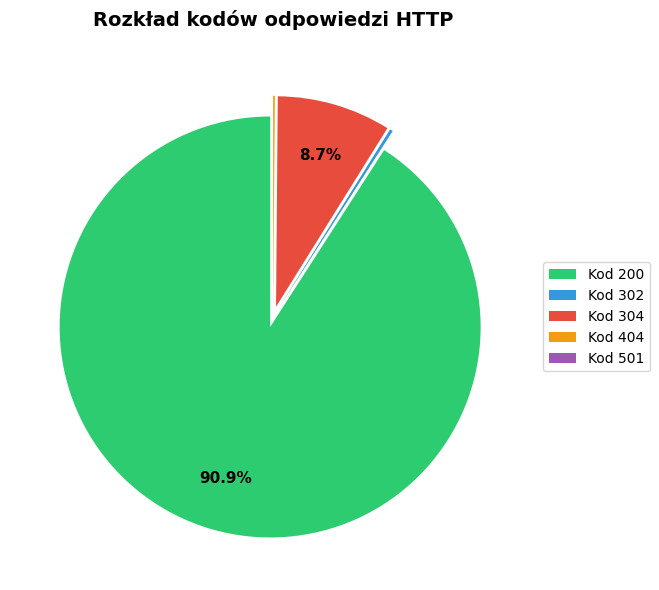


Rozkład kodów HTTP (powyżej):
  Kod 200: 2,684,306 (90.89%)
  Kod 302: 6,912 (0.23%)
  Kod 304: 258,161 (8.74%)
  Kod 404: 3,858 (0.13%)
  Kod 501: 30 (0.00%)


In [49]:

import matplotlib.pyplot as plt

http_codes_data = dataFrame.groupBy("response").count().orderBy("response").collect()
codes = [str(row['response']) for row in http_codes_data]
counts = [row['count'] for row in http_codes_data]
total = sum(counts)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22']
explode = [0.05] * len(codes)

wedges, texts, autotexts = ax.pie(
    counts,
    labels=None,
    autopct=lambda pct: f'{pct:.1f}%' if pct > 2 else '',
    colors=colors[:len(codes)],
    explode=explode,
    startangle=90,
    textprops={'fontsize': 11, 'weight': 'bold'},
    pctdistance=0.75
)

legend_labels = [f'Kod {codes[i]}' for i in range(len(codes))]
ax.legend(wedges, legend_labels, loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=10)

ax.set_title('Rozkład kodów odpowiedzi HTTP', fontsize=14, weight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\nRozkład kodów HTTP (powyżej):")
for i in range(len(codes)):
    print(f"  Kod {codes[i]}: {counts[i]:,} ({counts[i]/total*100:.2f}%)")


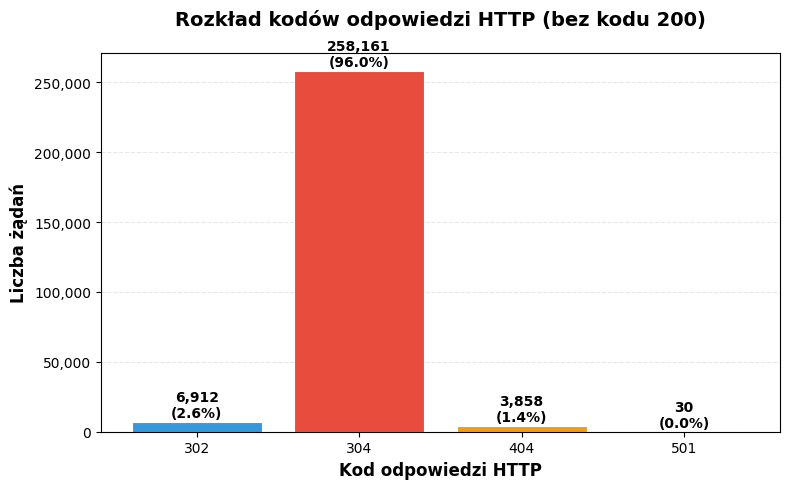


Kody HTTP inne niż 200:
  Kod 302: 6,912 (2.57%)
  Kod 304: 258,161 (95.98%)
  Kod 404: 3,858 (1.43%)
  Kod 501: 30 (0.01%)


In [50]:

import matplotlib.pyplot as plt

non200_data = dataFrame.filter(col("response") != 200).groupBy("response").count().orderBy("response").collect()
non200_codes = [str(row['response']) for row in non200_data]
non200_counts = [row['count'] for row in non200_data]
non200_total = sum(non200_counts)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#3498db', '#e74c3c', '#f39c12', '#9b59b6', '#1abc9c']
bars = ax.bar(non200_codes, non200_counts, color=colors[:len(non200_codes)], edgecolor='white', linewidth=0.8)

for bar, count in zip(bars, non200_counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + non200_total * 0.005,
        f'{count:,}\n({count/non200_total*100:.1f}%)',
        ha='center', va='bottom', fontsize=10, weight='bold'
    )

ax.set_xlabel('Kod odpowiedzi HTTP', fontsize=12, weight='bold')
ax.set_ylabel('Liczba żądań', fontsize=12, weight='bold')
ax.set_title('Rozkład kodów odpowiedzi HTTP (bez kodu 200)', fontsize=14, weight='bold', pad=20)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

print("\nKody HTTP inne niż 200:")
for code, count in zip(non200_codes, non200_counts):
    print(f"  Kod {code}: {count:,} ({count/non200_total*100:.2f}%)")


## 10 najbardziej aktywnych adresów IP

In [51]:
print("\n" + "=" * 80)
print("(c) 10 NAJBARDZIEJ AKTYWNYCH ADRESÓW IP")
print("=" * 80)

top_ips = dataFrame.groupBy("host").count().orderBy(col("count").desc()).limit(10)
top_ips = top_ips.select(
    col("host").alias("Adres IP"),
    col("count").alias("Liczba zapytań")
)
top_ips.show(10, truncate=False)

# Zapisanie do zmiennej
top_ips_list = dataFrame.groupBy("host").count().orderBy(col("count").desc()).limit(10).collect()
print(f"\nRazem zapytań z TOP 10 IP: {sum([row['count'] for row in top_ips_list])}")
total_requests_c = dataFrame.count()
top_10_percentage = (sum([row['count'] for row in top_ips_list]) / total_requests_c) * 100
print(f"To stanowi {top_10_percentage:.2f}% wszystkich zapytań")



(c) 10 NAJBARDZIEJ AKTYWNYCH ADRESÓW IP
+--------------------+--------------+
|Adres IP            |Liczba zapytań|
+--------------------+--------------+
|piweba3y.prodigy.com|19257         |
|piweba4y.prodigy.com|14510         |
|edams.ksc.nasa.gov  |11472         |
|piweba1y.prodigy.com|10931         |
|163.206.89.4        |7856          |
|siltb10.orl.mmc.com |7573          |
|alyssa.prodigy.com  |7097          |
|news.ti.com         |6805          |
|www-d1.proxy.aol.com|6580          |
|piweba2y.prodigy.com|6286          |
+--------------------+--------------+


Razem zapytań z TOP 10 IP: 98367
To stanowi 3.33% wszystkich zapytań


## Liczba zapytań w podziale na godziny

In [52]:
print("\n" + "=" * 80)
print("(d) LICZBA ZAPYTAŃ W PODZIALE NA GODZINY")
print("=" * 80)

from pyspark.sql.functions import hour

hourly_requests = dataFrame.withColumn("hour", hour(col("time"))).groupBy("hour").count().orderBy("hour")
hourly_requests = hourly_requests.select(
    col("hour").alias("Godzina"),
    col("count").alias("Liczba zapytań")
)
hourly_requests.show(24, truncate=False)

hourly_data = dataFrame.withColumn("hour", hour(col("time"))).groupBy("hour").count().collect()
print(f"\nSrednio zapytań na godzinę: {sum([row['count'] for row in hourly_data]) / 24:.0f}")
max_hour = max(hourly_data, key=lambda x: x['count'])
min_hour = min(hourly_data, key=lambda x: x['count'])
print(f"Szczyt w godzinie {max_hour['hour']}: {max_hour['count']} zapytań")
print(f"Dołek w godzinie {min_hour['hour']}: {min_hour['count']} zapytań")



(d) LICZBA ZAPYTAŃ W PODZIALE NA GODZINY
+-------+--------------+
|Godzina|Liczba zapytań|
+-------+--------------+
|0      |122869        |
|1      |110509        |
|2      |109921        |
|3      |110883        |
|4      |111973        |
|5      |105857        |
|6      |93410         |
|7      |76933         |
|8      |65135         |
|9      |56394         |
|10     |50026         |
|11     |49634         |
|12     |57391         |
|13     |88054         |
|14     |129675        |
|15     |155142        |
|16     |167593        |
|17     |181383        |
|18     |195288        |
|19     |192621        |
|20     |191037        |
|21     |196689        |
|22     |185062        |
|23     |149788        |
+-------+--------------+


Srednio zapytań na godzinę: 123053
Szczyt w godzinie 21: 196689 zapytań
Dołek w godzinie 11: 49634 zapytań


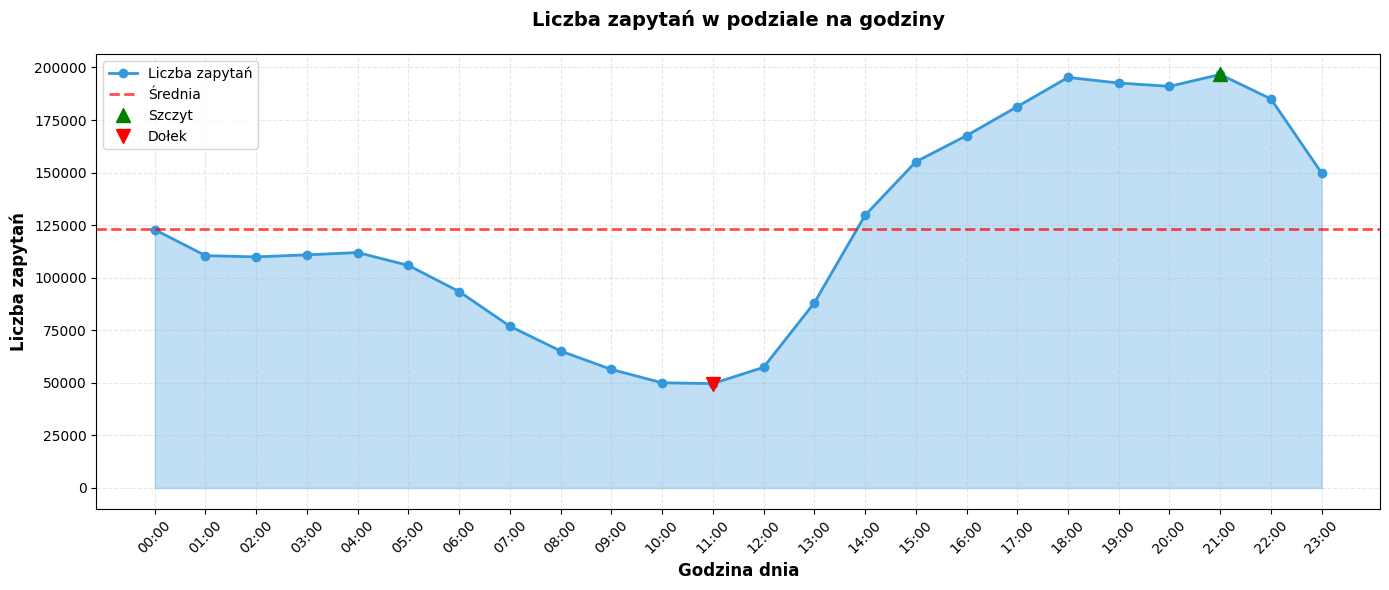


Statystyki godzinowe (powyżej):
  Średnia: 123053 zapytań/godzinę
  Min: 49,634 zapytań (godzina 11:00)
  Max: 196,689 zapytań (godzina 21:00)


In [53]:
import matplotlib.pyplot as plt
from pyspark.sql.functions import hour, col

hourly_data_for_plot = dataFrame.withColumn("hour", hour(col("time"))).groupBy("hour").count().orderBy("hour").toPandas()
hours = hourly_data_for_plot['hour'].tolist()
requests = hourly_data_for_plot['count'].tolist()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(hours, requests, marker='o', linewidth=2, markersize=6, color='#3498db', label='Liczba zapytań')

ax.fill_between(hours, requests, alpha=0.3, color='#3498db')

ax.set_xlabel('Godzina dnia', fontsize=12, weight='bold')
ax.set_ylabel('Liczba zapytań', fontsize=12, weight='bold')
ax.set_title('Liczba zapytań w podziale na godziny', fontsize=14, weight='bold', pad=20)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xticks(hours)
ax.set_xticklabels([f'{h:02d}:00' for h in hours], rotation=45)

average = sum(requests) / len(requests)
ax.axhline(y=average, color='red', linestyle='--', linewidth=2, label=f'Średnia', alpha=0.7)

max_hour_idx = requests.index(max(requests))
min_hour_idx = requests.index(min(requests))
ax.plot(hours[max_hour_idx], requests[max_hour_idx], 'g^', markersize=10, label=f'Szczyt')
ax.plot(hours[min_hour_idx], requests[min_hour_idx], 'rv', markersize=10, label=f'Dołek')

ax.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

print("\nStatystyki godzinowe (powyżej):")
print(f"  Średnia: {average:.0f} zapytań/godzinę")
print(f"  Min: {min(requests):,} zapytań (godzina {hours[min_hour_idx]}:00)")
print(f"  Max: {max(requests):,} zapytań (godzina {hours[max_hour_idx]}:00)")


## Liczba zapytań dla każdej metody HTTP

In [54]:
print("\n" + "=" * 80)
print("(e) LICZBA ZAPYTAŃ DLA KAŻDEJ METODY HTTP")
print("=" * 80)

http_methods = dataFrame.groupBy("method").count().orderBy(col("count").desc()).select(
    col("method").alias("Metoda HTTP"),
    col("count").alias("Liczba zapytań")
)
http_methods.show(truncate=False)

method_data = dataFrame.groupBy("method").count().collect()
total_requests_e = dataFrame.count()
print(f"\nRazem zapytań: {total_requests_e}")
for row in sorted(method_data, key=lambda x: x['count'], reverse=True):
    method = row['method']
    count = row['count']
    percentage = (count / total_requests_e) * 100
    print(f"  {method:6s}: {count:8d} ({percentage:6.2f}%)")



(e) LICZBA ZAPYTAŃ DLA KAŻDEJ METODY HTTP
+-----------+--------------+
|Metoda HTTP|Liczba zapytań|
+-----------+--------------+
|GET        |2953234       |
|POST       |30            |
|HEAD       |3             |
+-----------+--------------+


Razem zapytań: 2953267
  GET   :  2953234 (100.00%)
  POST  :       30 (  0.00%)
  HEAD  :        3 (  0.00%)


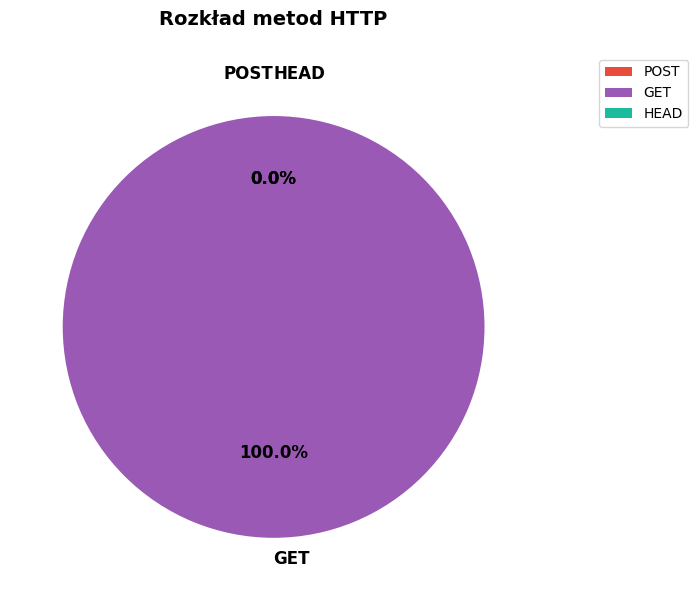


Rozkład metod HTTP (powyżej):
  POST  : 30 (0.00%)
  GET   : 2,953,234 (100.00%)
  HEAD  : 3 (0.00%)


In [55]:
import matplotlib.pyplot as plt

methods_data = dataFrame.groupBy("method").count().collect()
methods = [row['method'] for row in methods_data]
method_counts = [row['count'] for row in methods_data]

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#e74c3c', '#9b59b6', '#1abc9c', '#f39c12', '#34495e']
explode = [0.05] * len(methods)

wedges, texts, autotexts = ax.pie(method_counts, labels=methods, autopct='%1.1f%%', 
                                    colors=colors[:len(methods)], explode=explode, startangle=90,
                                    textprops={'fontsize': 12, 'weight': 'bold'})

# Dodanie legendy z liczbami
legend_labels = [f'{methods[i]}' for i in range(len(methods))]
ax.legend(legend_labels, loc='upper right', bbox_to_anchor=(1.3, 1), fontsize=10)

ax.set_title('Rozkład metod HTTP', fontsize=14, weight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\nRozkład metod HTTP (powyżej):")
for i in range(len(methods)):
    print(f"  {methods[i]:6s}: {method_counts[i]:,} ({method_counts[i]/sum(method_counts)*100:.2f}%)")


## 10 najczęstszych błędów 404 (adresy URL)

In [56]:

print("\n" + "=" * 80)
print("(f) 10 NAJCZĘSTSZYCH BŁĘDÓW 404 (ADRESY URL)")
print("=" * 80)

errors_404 = dataFrame.filter(col("response") == 404)

# Technika optymalizacyjna (a): persist() dla pośredniego DataFrame
# errors_404 jest używany dwukrotnie (count + groupBy), więc persist() zapobiega
# podwójnemu przeliczaniu filtra na głównym dataFrame (który jest już w cache).
errors_404.persist()

print(f"Razem błędów 404: {errors_404.count()}")

top_404_urls = errors_404.groupBy("url").count().orderBy(col("count").desc()).limit(10)
top_404_urls = top_404_urls.select(
    col("url").alias("Adres URL (404)"),
    col("count").alias("Liczba błędów")
)
top_404_urls.show(10, truncate=False)

top_404_list = errors_404.groupBy("url").count().orderBy(col("count").desc()).limit(10).collect()
print(f"\nRazem błędów 404 w TOP 10: {sum([row['count'] for row in top_404_list])}")

total_requests_f = dataFrame.count()
error_404_percentage = (errors_404.count() / total_requests_f) * 100
print(f"Błędy 404 stanowią {error_404_percentage:.2f}% wszystkich zapytań")

errors_404.unpersist()



(f) 10 NAJCZĘSTSZYCH BŁĘDÓW 404 (ADRESY URL)
Razem błędów 404: 3858
+-------------------------------------------------+-------------+
|Adres URL (404)                                  |Liczba błędów|
+-------------------------------------------------+-------------+
|/pub/winvn/readme.txt                            |2004         |
|/pub/winvn/release.txt                           |1732         |
|/shuttle/countdown/video/livevideo.jpeg          |101          |
|/shuttle/missions/sts-69/images/images.html      |7            |
|/shuttle/missions/sts-70/images/images.html      |4            |
|/shuttle/missions/sts-70/images/DSC-95EC-0001.jpg|3            |
|/elv/new01.gif                                   |2            |
|/shuttle/missions/sts-70/movies/movies.html      |2            |
|/elv/updated.gif                                 |1            |
|/elv/struct.gif                                  |1            |
+-------------------------------------------------+-------------+


Razem

DataFrame[host: string, time: timestamp, method: string, url: string, response: smallint, bytes: bigint]